# Joint Multi-System Fit — No Expert Shifts

Same as notebook 11, but with `USE_EXPERT_SHIFTS=False`: all experts share $b = 0$.

**Hypothesis:** removing expert-specific location shifts will let chicken ratings flow through to $q_j$ and $C$ directly, rather than being absorbed by Hayley's $b_e = 1.75$.

**Comparison points (from notebook 11, WITH expert shifts):**
| System | P(C=1) with shifts | a (shared) |
|---|---|---|
| Chicken | 0.096 | 2.749 |
| LLMs | 0.093 | 2.749 |

In [1]:
import os, sys, warnings, time

os.environ["PYTENSOR_FLAGS"] = f"compiledir=/tmp/pytensor_cache_nb12_{os.getpid()}"
sys.path.insert(0, "..")
os.chdir(os.path.join(os.path.dirname(os.path.abspath("."))))
warnings.filterwarnings("ignore", message="Loop fusion failed")

import numpy as np
import arviz as az
import matplotlib.pyplot as plt

from dcm_model import ModelConfig, load_data, fit_stance_multisystem

plt.rcParams.update(
    {"figure.dpi": 120, "font.size": 10, "figure.constrained_layout.use": True}
)

In [2]:
STANCE = "Global Workspace Theory"
SYSTEM_CONFIGS = [
    ("Human", 0.999),
    ("Chicken", None),
    ("2024 Leading Chat LLMs", None),
    ("ELIZA", 0.001),
]

cfg = ModelConfig(
    USE_EXPERT_SHIFTS=False,  # <-- THE CHANGE
    NUM_SAMPLES=2000,
    NUM_TUNE=1500,
    NUM_CHAINS=4,
    TARGET_ACCEPT=0.9,
)

all_data = load_data(cfg)
stance_data = next(s for s in all_data if s["name"] == STANCE)

print("Joint fit WITHOUT expert-specific shifts (b_e = 0 for all)")
print(f"USE_EXPERT_SHIFTS = {cfg.USE_EXPERT_SHIFTS}")
print()

t0 = time.time()
idata, builder, processor = fit_stance_multisystem(stance_data, cfg, SYSTEM_CONFIGS)
elapsed = time.time() - t0
print(f"\nTotal elapsed: {elapsed:.0f}s")

Joint fit WITHOUT expert-specific shifts (b_e = 0 for all)
USE_EXPERT_SHIFTS = False



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [chicken__global_workspace_theory_C, 2024_leading_chat_llms__global_workspace_theory_C, a, kappa, representationality_beta_pres, representationality_beta_abs, conceptual_representations_beta_pres, conceptual_representations_beta_abs, activation_steering_effects_beta_pres, activation_steering_effects_beta_abs, probe-detectable_themes_beta_pres, probe-detectable_themes_beta_abs, concept-specific_ablation_effects_beta_pres, concept-specific_ablation_effects_beta_abs, propositional_representations_beta_pres, propositional_representations_beta_abs, logical_inference_beta_pres, logical_inference_beta_abs, world_modelling_beta_pres, world_modelling_beta_abs, model_isomorphism_beta_pres, model_isomorphism_beta_abs, broad_predictive_training_beta_pres, broad_predictive_training_beta_abs, isomorphic_representations_beta_pres, isomorphic_representations_beta_abs, somatotopic_neural_maps_beta_pres, somato

Output()

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 491 seconds.



Total elapsed: 5011s


In [3]:
# Extract per-system posteriors + compare to with-shifts results
stance_vn = builder.node_to_varname[STANCE]
post = idata.posterior

# With-shifts results for comparison (from notebook 11)
with_shifts = {"Chicken": 0.096, "2024 Leading Chat LLMs": 0.093}

print(
    f"{'System':<25s}  {'No shifts':>9s}  {'With shifts':>11s}  {'Change':>8s}  {'94% CI':>18s}"
)
print("-" * 80)
for sys_name, c_fixed in SYSTEM_CONFIGS:
    sp = builder._sys_prefix(sys_name)
    c_key = f"{sp}__{stance_vn}_C"
    if c_key in post:
        draws = post[c_key].values.flatten()
        m = float(draws.mean())
        lo, hi = float(np.percentile(draws, 3)), float(np.percentile(draws, 97))
        prev = with_shifts.get(sys_name, None)
        delta = f"{m - prev:+.3f}" if prev else "ref"
        print(
            f"{sys_name:<25s}  {m:>9.3f}  {prev if prev else c_fixed:>11.3f}  {delta:>8s}  [{lo:.3f}, {hi:.3f}]"
        )
    else:
        print(f"{sys_name:<25s}  {c_fixed:>9.3f}  {'':>11s}  {'fixed':>8s}")

# Observation layer
a_mean = float(post["a"].mean())
print(f"\nShared a (no shifts): {a_mean:.3f}   (was 2.749 with shifts)")

# Convergence
n_div = int(idata.sample_stats["diverging"].values.sum())
summary = az.summary(idata, var_names=["a", "kappa"], kind="diagnostics")
print(
    f"Divergences: {n_div}   max R-hat: {float(summary['r_hat'].max()):.3f}   min ESS: {float(summary['ess_bulk'].min()):.0f}"
)

System                     No shifts  With shifts    Change              94% CI
--------------------------------------------------------------------------------
Human                          0.999        0.999       ref  [0.999, 0.999]
Chicken                        0.273        0.096    +0.177  [0.017, 0.655]
2024 Leading Chat LLMs         0.109        0.093    +0.016  [0.004, 0.361]
ELIZA                          0.001        0.001       ref  [0.001, 0.001]

Shared a (no shifts): 1.906   (was 2.749 with shifts)
Divergences: 0   max R-hat: 1.000   min ESS: 6220


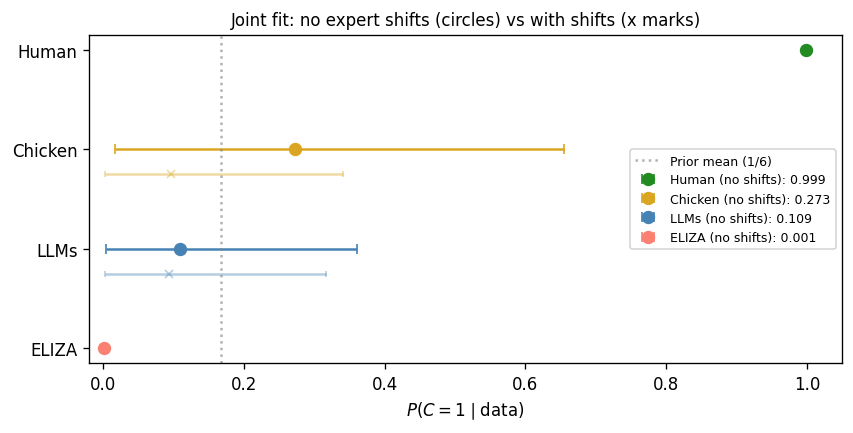

In [4]:
# Forest plot comparing with-shifts vs no-shifts
fig, ax = plt.subplots(figsize=(7, 3.5))
y = 0
yticks = []
ylabels = []
colours = {
    "Human": "forestgreen",
    "Chicken": "goldenrod",
    "2024 Leading Chat LLMs": "steelblue",
    "ELIZA": "salmon",
}
display = {"2024 Leading Chat LLMs": "LLMs"}
ws = {"Chicken": (0.096, 0.003, 0.340), "2024 Leading Chat LLMs": (0.093, 0.003, 0.317)}

for sys_name, c_fixed in SYSTEM_CONFIGS:
    sp = builder._sys_prefix(sys_name)
    c_key = f"{sp}__{stance_vn}_C"
    col = colours[sys_name]
    lbl = display.get(sys_name, sys_name)

    if c_key in post:
        draws = post[c_key].values.flatten()
        m, lo, hi = (
            float(draws.mean()),
            float(np.percentile(draws, 3)),
            float(np.percentile(draws, 97)),
        )
        err_lo = max(m - lo, 0)
        err_hi = max(hi - m, 0)
        ax.errorbar(
            [m],
            [y],
            xerr=[[err_lo], [err_hi]],
            fmt="o",
            color=col,
            capsize=3,
            markersize=7,
            label=f"{lbl} (no shifts): {m:.3f}",
        )
        if sys_name in ws:
            wm, wlo, whi = ws[sys_name]
            ax.errorbar(
                [wm],
                [y + 0.25],
                xerr=[[wm - wlo], [whi - wm]],
                fmt="x",
                color=col,
                capsize=2,
                markersize=5,
                alpha=0.4,
            )
    else:
        ax.plot(
            [c_fixed],
            [y],
            "D",
            color=col,
            markersize=8,
            label=f"{lbl} (ref): {c_fixed}",
        )
    yticks.append(y)
    ylabels.append(lbl)
    y += 1

ax.axvline(1 / 6, color="grey", linestyle=":", alpha=0.6, label="Prior mean (1/6)")
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, fontsize=10)
ax.set_xlabel(r"$P(C=1 \mid \text{data})$")
ax.set_xlim(-0.02, 1.05)
ax.invert_yaxis()
ax.legend(fontsize=7.5, loc="center right")
ax.set_title(
    "Joint fit: no expert shifts (circles) vs with shifts (x marks)", fontsize=10
)
plt.show()


## Stance prior sensitivity (importance resampling)

The paper's Appendix E sweeps the stance prior across {10%, 17%, 50%, 90%} mean consciousness probability. Rather than refitting (~75 min each), we **reweight** the existing posterior draws under different priors. This is exact when the new and old priors overlap sufficiently, which we check via effective sample size.

Prior settings tested:
- **Low:** Beta(1, 9), mean = 0.10
- **Baseline:** Beta(1, 5), mean = 0.167 (current)
- **Uniform:** Beta(1, 1), mean = 0.50
- **High:** Beta(9, 1), mean = 0.90

In [5]:
from scipy.stats import beta as beta_dist

# Posterior draws for the two target systems
stance_vn = builder.node_to_varname["Global Workspace Theory"]
chicken_sp = builder._sys_prefix("Chicken")
llm_sp = builder._sys_prefix("2024 Leading Chat LLMs")

chicken_draws = idata.posterior[f"{chicken_sp}__{stance_vn}_C"].values.flatten()
llm_draws = idata.posterior[f"{llm_sp}__{stance_vn}_C"].values.flatten()

# Original prior: Beta(1, 5)
orig_a, orig_b = 1, 5

PRIOR_CONFIGS = {
    "Low (0.10)": (1, 9),
    "Baseline (0.17)": (1, 5),
    "Uniform (0.50)": (1, 1),
    "High (0.90)": (9, 1),
}


def importance_resample(draws, orig_a, orig_b, new_a, new_b):
    """Reweight posterior draws under a new prior via importance sampling."""
    log_w = beta_dist.logpdf(draws, new_a, new_b) - beta_dist.logpdf(
        draws, orig_a, orig_b
    )
    log_w -= log_w.max()
    w = np.exp(log_w)
    w /= w.sum()
    ess = 1.0 / np.sum(w**2)
    wmean = np.average(draws, weights=w)
    # Weighted percentiles via sorted resampling
    idx = np.argsort(draws)
    cum_w = np.cumsum(w[idx])
    lo = float(draws[idx][np.searchsorted(cum_w, 0.03)])
    hi = float(draws[idx][np.searchsorted(cum_w, 0.97)])
    return wmean, lo, hi, ess


print(
    f"{'Prior':<20s}  {'Chicken':>8s}  {'Chicken CI':>18s}  {'LLMs':>8s}  {'LLMs CI':>18s}  {'ESS':>6s}"
)
print("-" * 90)

results_by_prior = {}
for label, (a, b) in PRIOR_CONFIGS.items():
    cm, clo, chi, c_ess = importance_resample(chicken_draws, orig_a, orig_b, a, b)
    lm, llo, lhi, l_ess = importance_resample(llm_draws, orig_a, orig_b, a, b)
    min_ess = min(c_ess, l_ess)
    results_by_prior[label] = {
        "chicken": (cm, clo, chi),
        "llm": (lm, llo, lhi),
        "ess": min_ess,
    }
    print(
        f"{label:<20s}  {cm:>8.3f}  [{clo:.3f}, {chi:.3f}]  {lm:>8.3f}  [{llo:.3f}, {lhi:.3f}]  {min_ess:>6.0f}"
    )


Prior                  Chicken          Chicken CI      LLMs             LLMs CI     ESS
------------------------------------------------------------------------------------------
Low (0.10)               0.145  [0.006, 0.426]     0.075  [0.003, 0.249]    5136
Baseline (0.17)          0.273  [0.017, 0.655]     0.109  [0.004, 0.361]    8000
Uniform (0.50)           0.649  [0.158, 0.901]     0.231  [0.008, 0.795]      92
High (0.90)              0.834  [0.657, 0.901]     0.761  [0.555, 0.795]       2


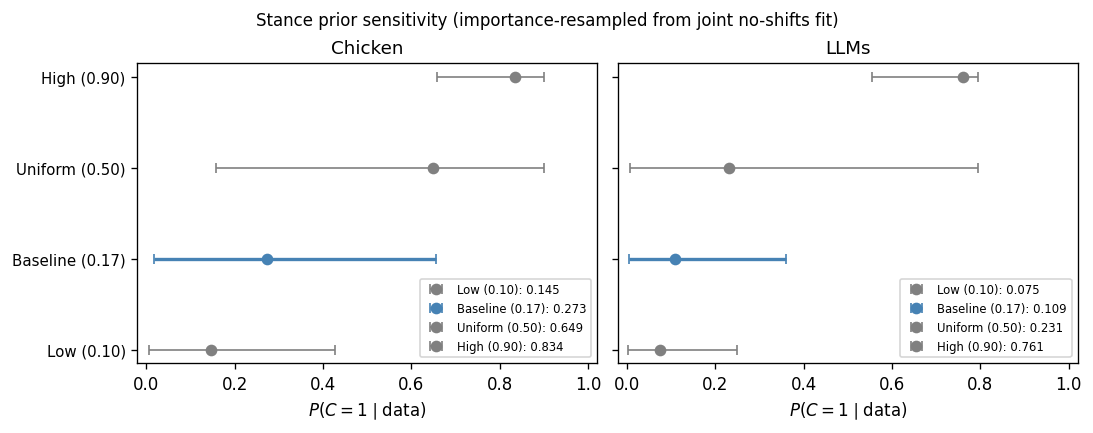

In [6]:
# Prior sensitivity forest plot (mirroring DCM paper Appendix E style)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)

for ax, (sys_label, sys_key) in zip(axes, [("Chicken", "chicken"), ("LLMs", "llm")]):
    for i, (label, res) in enumerate(results_by_prior.items()):
        m, lo, hi = res[sys_key]
        col = "steelblue" if "Baseline" in label else "grey"
        lw = 2 if "Baseline" in label else 1
        ax.errorbar(
            [m],
            [i],
            xerr=[[max(m - lo, 0)], [max(hi - m, 0)]],
            fmt="o",
            color=col,
            capsize=3,
            markersize=6,
            linewidth=lw,
            label=f"{label}: {m:.3f}",
        )
    ax.set_yticks(range(len(PRIOR_CONFIGS)))
    ax.set_yticklabels(list(PRIOR_CONFIGS.keys()), fontsize=9)
    ax.set_xlabel(r"$P(C=1 \mid \text{data})$")
    ax.set_title(sys_label, fontsize=11)
    ax.set_xlim(-0.02, 1.02)
    ax.invert_yaxis()
    ax.legend(fontsize=7, loc="lower right")

fig.suptitle(
    "Stance prior sensitivity (importance-resampled from joint no-shifts fit)",
    fontsize=10,
)
plt.show()


### Interpretation

**What to look for:**
- If posteriors **track the prior** (Low→low, High→high with proportional shifts): data is not overriding the prior — the same prior-domination issue.  
- If posteriors are **robust to prior choice** (similar values across all priors): the data is genuinely driving the result — ideal behaviour.
- If ESS < 100 for any prior: the importance weights are too extreme and those resampled estimates are unreliable. Would need a fresh MCMC fit at that prior instead.

Compare to the paper's Appendix E Figure (prior sensitivity across systems and stances) to see if the ordinal model's sensitivity pattern matches or differs from the legacy model's.